<a href="https://colab.research.google.com/github/alvaroanussa13-glitch/Projecto-de-aprendizado-de-m-quina-inibidores-InhA/blob/main/3_EDA_TKI_HER2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Desenvolvimento de modelos de machine learning baseados em QSAR-2D para a predição de novos candidatos a fármacos inibidores de Enoyl-ACP Reductase para tratamento de tuberculose***

---



*@Alvaro_Anussa*

### ***2. Machine Learning & QSAR-2D***

### ***2.3. Análise exploratória dos TKI-HER2***

### **Pipeline**
1. Configuração do ambiente de trabalho
2. Carregamento dos dados em .csv
3. Realização da estatística descritiva
4. Aplicação do teste de normalidade dos dados
5. Frequência de compostos por classe***
6. Execução do teste de Mann–Whitney U (teste não-paramétrico)
7. Gráfico A - Boxplot: aceitadores de H vs classe
8. Gráfico B - Boxplot: doadores de H vs classe
9. Gráfico C - Dispersão: LogP vs Massa Molecular
10. Gráfico D - Boxplot: LogP vs classe

### ***1. Configuração do ambiente de trabalho***

In [1]:
import numpy as np # Operações matemáticas
import pandas as pd # Tabulação de dados
import seaborn as sns # Visualização de dados em gráficos estatísticos
import matplotlib.pyplot as plt # Visualização de dados em gráficos básicos
from scipy import stats # Cálculos estatísticos

### ***2. Carregamento dos dados em .csv***

In [2]:
df_final = pd.read_csv("Dados para EDA.csv")

### ***3. Realização da estatística descritiva***

In [3]:
# Estatísticas descritivas por classe com base nos descritores de Lipinski
df_final.groupby('Classe')[['MolLogP', 'MolWt', 'nHBDon', 'nHBAcc']].describe()

MolLogP                                                         \
         count      mean       std     min       25%      50%     75%   
Classe                                                                  
0        254.0  3.858386  1.258546 -0.3149  3.224855  3.92515  4.5925   
1        144.0  3.604804  1.512998 -2.3899  2.408525  3.86500  4.6039   

                 MolWt              ... nHBDon      nHBAcc            \
            max  count        mean  ...    75%  max  count      mean   
Classe                              ...                                
0       7.43332  254.0  367.003591  ...    1.0  8.0  254.0  3.775591   
1       6.61410  144.0  439.886618  ...    2.0  8.0  144.0  5.243056   

                                            
             std  min  25%  50%  75%   max  
Classe                                      
0       2.004154  1.0  2.0  3.0  5.0  17.0  
1       2.613163  2.0  3.0  5.0  7.0  18.0  

[2 rows x 32 columns]

### ***4. Aplicação do teste de normalidade dos dados***

In [4]:
#Verificar normalidade com Shapiro-Wilk
# Rotular a classe de bioactividade
df_final['classe_bioatividade'] = df_final['Classe'].map({1: 'Ativo', 0: 'Inativo'})

# Separar grupos
ativos = df_final[df_final['classe_bioatividade'] == 'Ativo']
inativos = df_final[df_final['classe_bioatividade'] == 'Inativo']

In [5]:
# Loop para execução de teste de normalidade para as features de Lipinski
for coluna in ['MolLogP', 'nHBDon', 'nHBAcc']:
    print(f"\nTeste de normalidade para '{coluna}':")
    stat_ativo, p_ativo = stats.shapiro(ativos[coluna])
    stat_inativo, p_inativo = stats.shapiro(inativos[coluna])
    print(f"Ativos: p={p_ativo:.4f} {'(normal)' if p_ativo>0.05 else '(não normal)'}")
    print(f"Inativos: p={p_inativo:.4f} {'(normal)' if p_inativo>0.05 else '(não normal)'}")


Teste de normalidade para 'MolLogP':
Ativos: p=0.0042 (não normal)
Inativos: p=0.0010 (não normal)

Teste de normalidade para 'nHBDon':
Ativos: p=0.0000 (não normal)
Inativos: p=0.0000 (não normal)

Teste de normalidade para 'nHBAcc':
Ativos: p=0.0000 (não normal)
Inativos: p=0.0000 (não normal)


### ***5. Frequência de compostos por classe***

/tmp/ipykernel_5626/760188588.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_final, x='classe_bioatividade', palette=cores)


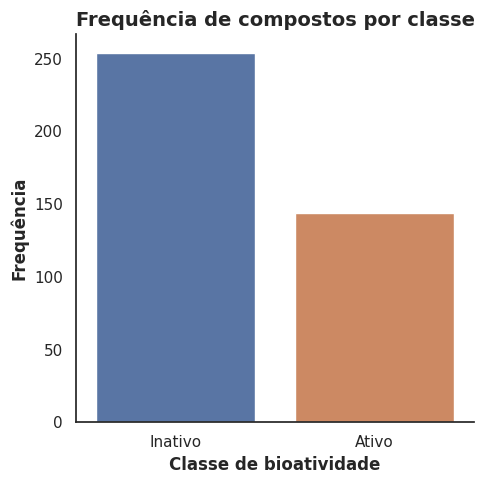

In [6]:
# Mapeia a classe para nome legível (como já foi feito)
df_final['classe_bioatividade'] = df_final['Classe'].map({1: 'Ativo', 0: 'Inativo'})

# Estilo visual
sns.set(style="white", context='notebook')
plt.figure(figsize=(5, 5))

# Cores azul escuro e laranja queimado
cores = ['#4C72B0', '#DD8452']

# Plot da contagem
ax = sns.countplot(data=df_final, x='classe_bioatividade', palette=cores)

# Eixos e título
ax.set_xlabel('Classe de bioatividade', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('Frequência de compostos por classe', fontsize=14, fontweight='bold')

# Grade e estilo limpo
sns.despine()
plt.tight_layout()

# Salvar o gráfico em PNG
plt.savefig("Frequencia_classes.png", dpi=300, bbox_inches='tight')

plt.show()

### ***6. Execução do teste de Mann–Whitney U (teste não-paramétrico) em Hipóteses estatísticas***

In [7]:
# Lista de descritores que deseja comparar
variaveis = ['MolLogP', 'nHBDon', 'nHBAcc']

# Lista para acumular os resultados
resultados = []

# Loop pelos descritores
for coluna in variaveis:
    # Valores ativos e inativos
    vals_ativos = ativos[coluna]
    vals_inativos = inativos[coluna]

    # Teste Mann–Whitney U
    _, p = stats.mannwhitneyu(vals_ativos, vals_inativos, alternative='two-sided')

    # Hipóteses
    H0 = "H0: Ativos e inativos seguem a mesma distribuição (não há diferença)"
    H1 = "H1: Ativos e inativos seguem distribuições diferentes"

    # Interpretação
    if p < 0.05:
        interpretacao = "Rejeita H0 → distribuições diferentes (aceita H1)"
    else:
        interpretacao = "Não rejeita H0 → distribuições semelhantes"

    # Adicionar resultados à lista
    resultados.append({
        'Feature': coluna,
        'Valor-p': p,
        'Interpretação': interpretacao
    })

# Criar DataFrame final
df_resultados = pd.DataFrame(resultados)

In [8]:
df_resultados

,Feature,Valor-p,Interpretação
0,MolLogP,1.479568e-01,Não rejeita H0 → distribuições semelhantes
1,nHBDon,2.787393e-17,Rejeita H0 → distribuições diferentes (aceita H1)
2,nHBAcc,2.261755e-09,Rejeita H0 → distribuições diferentes (aceita H1)


### ***7. Gráfico A - Boxplot: aceitadores de H vs classe***

In [9]:
#Definir estilo visual inspirado na imagem
sns.set(style="white", font_scale=1.1)
custom_palette = {'Ativo': '#4C72B0', 'Inativo': '#DD8452'}

/tmp/ipykernel_5626/1536068260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_5626/1536068260.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)


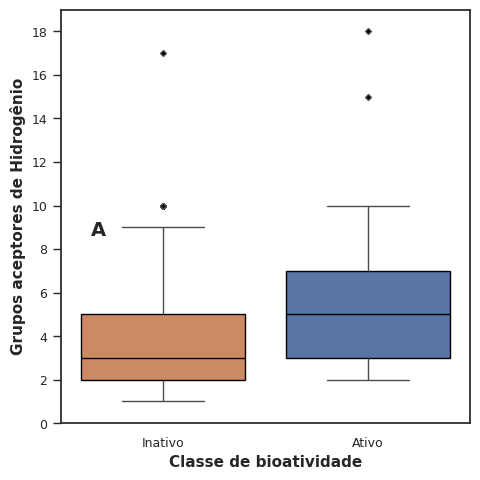

In [10]:
# Gráfico A - Boxplot: aceitadores de H vs classe
plt.figure(figsize=(5, 5))
ax = sns.boxplot(
    x='classe_bioatividade', y='nHBAcc', data=df_final,
    palette=custom_palette,
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='black', marker='D', markersize=3, linestyle='none')
)

# Título "A" grande no canto superior esquerdo
plt.text(-0.35, df_final['nHBAcc'].max() * 0.48, 'A', fontsize=14, fontweight='bold')

# Ajustar rótulos dos eixos em português e em negrito
plt.xlabel('Classe de bioatividade', fontsize=11, fontweight='bold')
plt.ylabel('Grupos aceptores de Hidrogênio', fontsize=11, fontweight='bold')

# Diminuir o tamanho das categorias "Ativo" e "Inativo"
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

ax.set_yticks(np.arange(0, 19, 2))
ax.set_ylim(0, 19)

# Tamanho dos ticks
ax.tick_params(axis='both', labelsize=9)

# Força a exibição de ticks no eixo Y
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_markersize(6)

# Também ajusta o comprimento e direção
ax.tick_params(axis='y', which='both', length=6, direction='out', width=1)
plt.tight_layout()
plt.savefig("A.png", dpi=300, bbox_inches='tight')
plt.show()

### ***8. Gráfico B - Boxplot: doadores de H vs classe***

/tmp/ipykernel_5626/2720993566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_5626/2720993566.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)


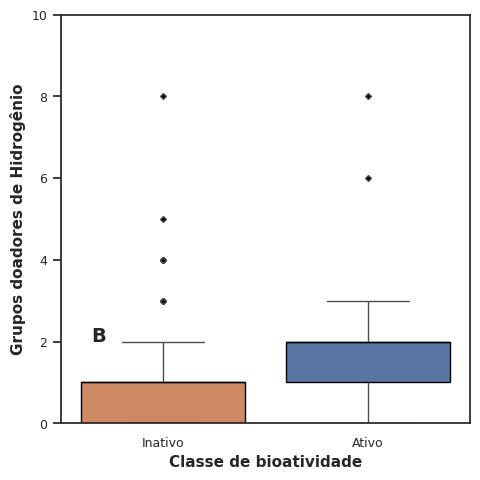

In [11]:
#Gráfico B - Boxplot: doadores de H vs classe
plt.figure(figsize=(5, 5))
ax = sns.boxplot(
    x='classe_bioatividade', y='nHBDon', data=df_final,
    palette=custom_palette,
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='black', marker='D', markersize=3, linestyle='none')
)
plt.text(-0.35, df_final['nHBDon'].max() * 0.25, 'B', fontsize=14, fontweight='bold')
plt.xlabel('Classe de bioatividade', fontsize=11, fontweight='bold')
plt.ylabel('Grupos doadores de Hidrogênio', fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

# Ajustar escala do eixo y
ax.set_yticks(np.arange(0, 12, 2))
ax.set_ylim(0, 10)
ax.tick_params(axis='both', labelsize=9)

# Força a exibição de ticks no eixo Y
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_markersize(6)  # tamanho do tracinho

plt.tight_layout()
plt.savefig("B.png", dpi=300, bbox_inches='tight')
plt.show()

### ***9. Gráfico C - Dispersão: LogP vs Massa Molecular***

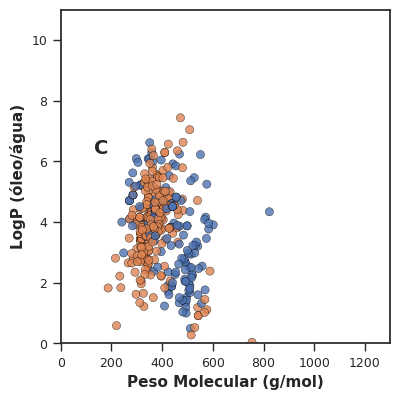

In [12]:
plt.figure(figsize=(4.2, 4.2))
ax = sns.scatterplot(
    data=df_final,
    x='MolWt', y='MolLogP',
    hue='classe_bioatividade',
    palette=custom_palette,
    s=35, alpha=0.8,
    edgecolor='black', linewidth=0.3
)

# Letra "C"
plt.text(
    df_final['MolWt'].min() * 0.95, df_final['MolLogP'].max() * 0.84,
    'C', fontsize=14, fontweight='bold'
)

# Rótulos invertidos
plt.xlabel('Peso Molecular (g/mol)', fontsize=11, fontweight='bold')
plt.ylabel('LogP (óleo/água)', fontsize=11, fontweight='bold')

# Remover legenda
ax.legend().remove()

# Ticks com intervalos definidos
ax.set_xticks(np.arange(0, 1300, 200))  # Peso molecular no eixo X
ax.set_yticks(np.arange(0, 12, 2))        # LogP no eixo Y
ax.tick_params(axis='both', labelsize=9)

plt.xlim(0, 1300)
plt.ylim(0, 11)

# Garante ticks no eixo X (embaixo)
ax.tick_params(axis='x', which='both', bottom=True, top=False, length=6, direction='out', width=1)

# Garante ticks no eixo Y (esquerdo)
ax.tick_params(axis='y', which='both', left=True, right=False, length=6, direction='out', width=1)


plt.tight_layout()
plt.savefig("C.png", dpi=300, bbox_inches='tight')
plt.show()


### ***10. Gráfico D - Boxplot: LogP vs classe***

/tmp/ipykernel_5626/92300092.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_5626/92300092.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)


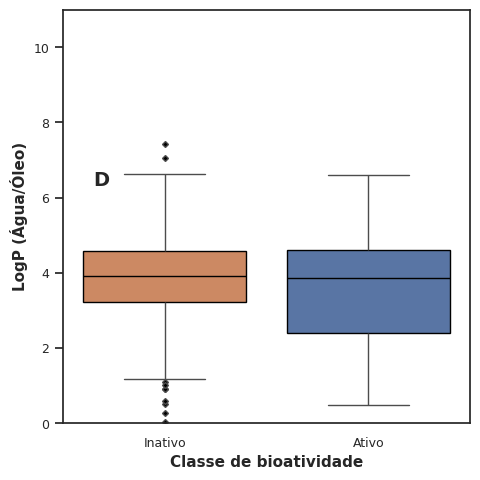

In [13]:
#Gráfico D - Boxplot: LogP vs classe
plt.figure(figsize=(5, 5))
ax = sns.boxplot(
    x='classe_bioatividade', y='MolLogP', data=df_final,
    palette=custom_palette,
    boxprops=dict(edgecolor='black'),
    medianprops=dict(color='black'),
    flierprops=dict(markerfacecolor='black', marker='D', markersize=3, linestyle='none')
)
plt.text(-0.35, df_final['MolLogP'].max() * 0.85, 'D', fontsize=14, fontweight='bold')
plt.xlabel('Classe de bioatividade', fontsize=11, fontweight='bold')
plt.ylabel('LogP (Água/Óleo)', fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)

# Ajustar escala do eixo y
ax.set_yticks(np.arange(0, 11, 2))
ax.set_ylim(0, 11)
ax.tick_params(axis='both', labelsize=9)

# Força a exibição de ticks no eixo Y
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick1line.set_markersize(6)  # tamanho do tracinho

plt.tight_layout()
plt.savefig("D.png", dpi=300, bbox_inches='tight')
plt.show()

## **Fonte**
[Data Professor EDA](https://github.com/dataprofessor/code/blob/master/python/CDD_ML_Part_2_Exploratory_Data_Analysis.ipynb)


### ***FIM***